# DETR-Modelle vergleichen (alle Runs)

Lädt `metrics_summary.json` und `results.csv` aus **allen** Unterordnern von `runs/` (also allen über `scripts/train_detr.py` trainierten RT-DETR-Varianten) und vergleicht sie:
- Balkendiagramm: Wettbewerbsmetrik mAP@0.4 pro Modell
- Tabelle: alle Kennzahlen + Trainingszeit + Konfiguration pro Modell
- Per-Klasse-AP-Vergleich (Heatmap)
- Überlagerte Trainingskurven (Loss/mAP über Epochen)


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Try the cluster layout first, then common local layouts (repo root, or run from kaggle_notebooks/).
_candidates = [
    Path.home() / "dogs_project" / "cv" / "runs",
    Path.cwd() / "runs",
    Path.cwd().parent / "runs",
]
RUNS_DIR = next((p for p in _candidates if p.exists()), _candidates[-1])
print(f"Using RUNS_DIR = {RUNS_DIR}")

run_dirs = sorted([p for p in RUNS_DIR.iterdir() if (p / "metrics_summary.json").exists()])
print(f"Found {len(run_dirs)} completed runs: {[p.name for p in run_dirs]}")


Using RUNS_DIR = /mnt/c/Users/linap/OneDrive/Documents/Master/SoSe2026/computerVision/project/runs
Found 3 completed runs: ['rtdetr-l_1024', 'rtdetr-l_640', 'rtdetr-x_1024']


## Alle Kennzahlen laden

In [2]:
summaries = {}
for run_dir in run_dirs:
    with open(run_dir / "metrics_summary.json") as f:
        summaries[run_dir.name] = json.load(f)

rows = []
for name, s in summaries.items():
    rows.append({
        "run": name,
        "model": s["model"],
        "imgsz": s["imgsz"],
        "epochs": s["epochs"],
        "train_time_h": s["training_time_h"],
        "mAP@0.4 (competition)": s["competition_metric"]["map_at_0.4"],
        "precision": s["ultralytics_val_metrics"]["precision"],
        "recall": s["ultralytics_val_metrics"]["recall"],
        "mAP50": s["ultralytics_val_metrics"]["map50"],
        "mAP50-95": s["ultralytics_val_metrics"]["map50_95"],
    })

comparison_df = pd.DataFrame(rows).sort_values("mAP@0.4 (competition)", ascending=False)
comparison_df


,run,model,imgsz,epochs,train_time_h,mAP@0.4 (competition),precision,recall,mAP50,mAP50-95
1,rtdetr-l_640,rtdetr-l.pt,640,60,10.554,0.420374,0.401205,0.325835,0.310255,0.157036
0,rtdetr-l_1024,rtdetr-l.pt,1024,60,10.581,0.380415,0.359484,0.325400,0.277411,0.143078
2,rtdetr-x_1024,rtdetr-x.pt,1024,60,10.627,0.323879,0.383889,0.279946,0.232759,0.117163


## mAP@0.4 (Wettbewerbsmetrik) pro Modell

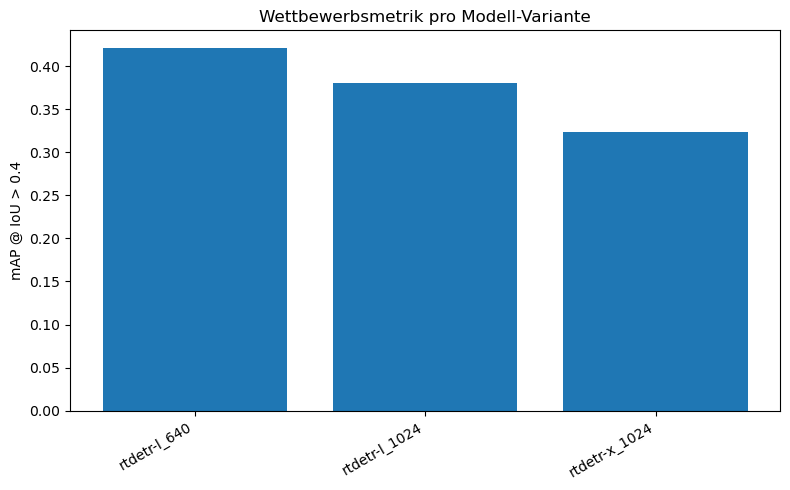

In [3]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["run"], comparison_df["mAP@0.4 (competition)"])
plt.ylabel("mAP @ IoU > 0.4")
plt.title("Wettbewerbsmetrik pro Modell-Variante")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Precision / Recall / mAP50 / mAP50-95 im Vergleich

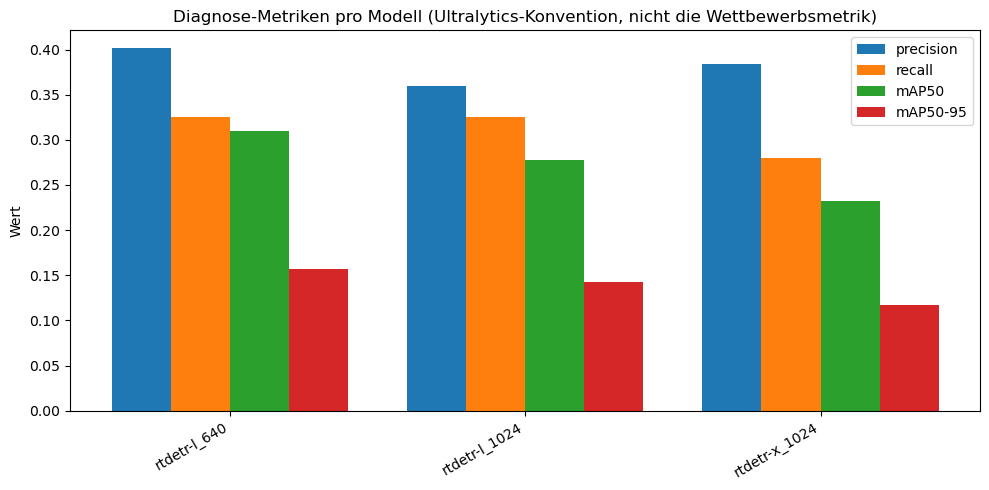

In [4]:
metrics_to_plot = ["precision", "recall", "mAP50", "mAP50-95"]
x = np.arange(len(comparison_df))
width = 0.2

plt.figure(figsize=(10, 5))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i * width, comparison_df[metric], width, label=metric)

plt.xticks(x + width * 1.5, comparison_df["run"], rotation=30, ha="right")
plt.ylabel("Wert")
plt.title("Diagnose-Metriken pro Modell (Ultralytics-Konvention, nicht die Wettbewerbsmetrik)")
plt.legend()
plt.tight_layout()
plt.show()


## Per-Klasse AP (mAP@0.4) über alle Modelle

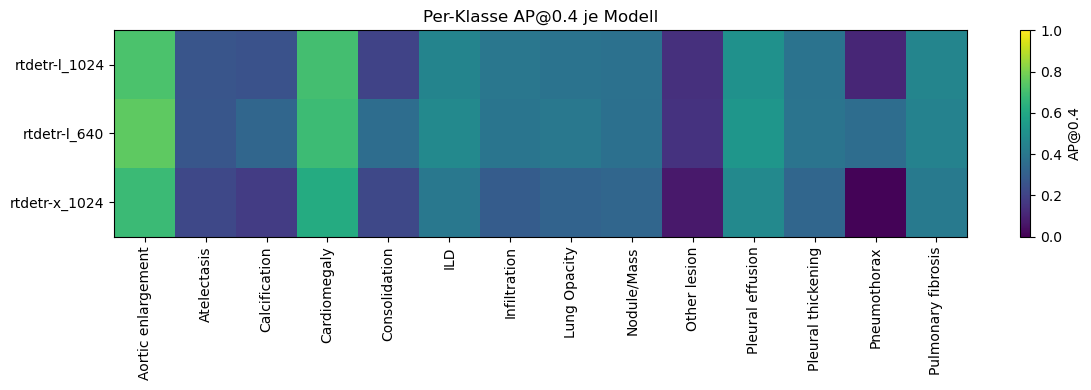

,Aortic enlargement,Atelectasis,Calcification,Cardiomegaly,Consolidation,ILD,Infiltration,Lung Opacity,Nodule/Mass,Other lesion,Pleural effusion,Pleural thickening,Pneumothorax,Pulmonary fibrosis
rtdetr-l_1024,0.716417,0.263985,0.251232,0.700954,0.200405,0.451452,0.396509,0.382532,0.371317,0.139898,0.505023,0.381535,0.107798,0.456750
rtdetr-l_640,0.751319,0.269286,0.331990,0.686630,0.358526,0.469522,0.388931,0.399713,0.370774,0.146891,0.524306,0.386603,0.355818,0.444929
rtdetr-x_1024,0.682196,0.217838,0.179436,0.615406,0.216535,0.399105,0.292315,0.318862,0.328585,0.066479,0.469734,0.328597,0.009413,0.409798


In [5]:
per_class_df = pd.DataFrame({
    name: s["competition_metric"]["per_class_ap"]
    for name, s in summaries.items()
}).T

if not per_class_df.empty:
    plt.figure(figsize=(12, max(4, 0.4 * len(per_class_df))))
    plt.imshow(per_class_df.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    plt.colorbar(label="AP@0.4")
    plt.yticks(range(len(per_class_df)), per_class_df.index)
    plt.xticks(range(len(per_class_df.columns)), per_class_df.columns, rotation=90)
    plt.title("Per-Klasse AP@0.4 je Modell")
    plt.tight_layout()
    plt.show()
else:
    print("Keine per-Klasse-AP-Daten gefunden (per_class_ap leer) — nur ein Datenpunkt?")

per_class_df


## Trainingszeit vs. Wettbewerbsmetrik (Effizienz-Trade-off)

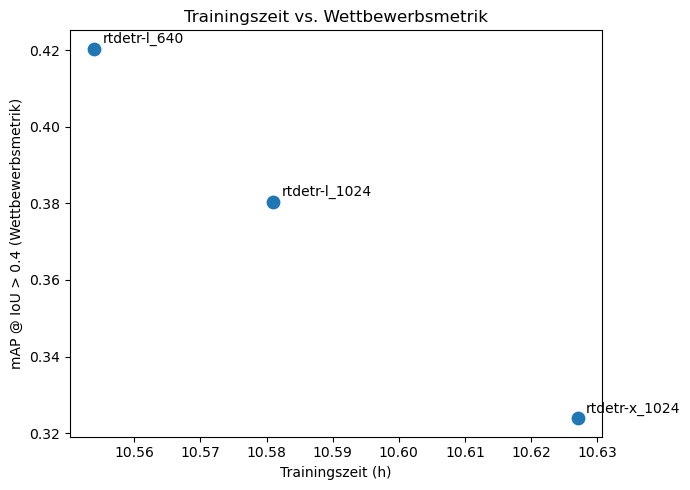

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(comparison_df["train_time_h"], comparison_df["mAP@0.4 (competition)"], s=80)
for _, row in comparison_df.iterrows():
    plt.annotate(row["run"], (row["train_time_h"], row["mAP@0.4 (competition)"]),
                 textcoords="offset points", xytext=(6, 4))
plt.xlabel("Trainingszeit (h)")
plt.ylabel("mAP @ IoU > 0.4 (Wettbewerbsmetrik)")
plt.title("Trainingszeit vs. Wettbewerbsmetrik")
plt.tight_layout()
plt.show()


## Trainingskurven überlagert

Nutzt `results.csv`, das Ultralytics automatisch pro Run in dessen Ordner ablegt (Spalten wie `epoch`, `train/box_loss`, `metrics/mAP50(B)`, ...).

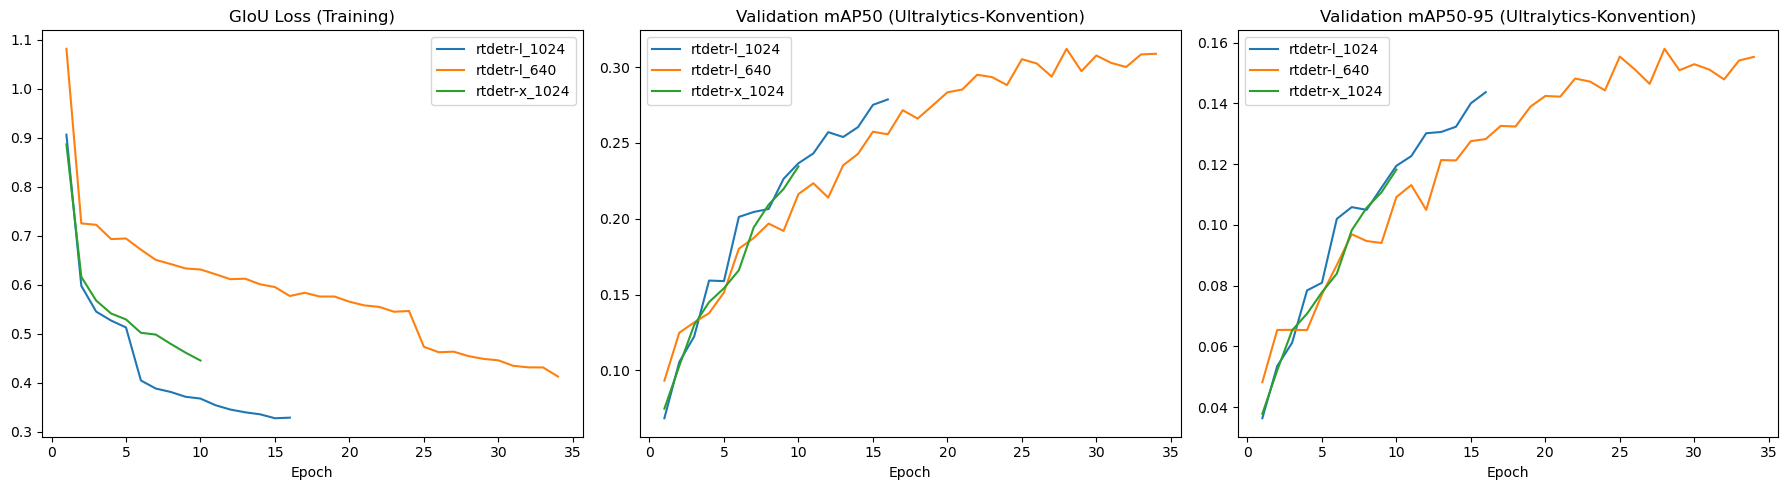

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for run_dir in run_dirs:
    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        continue
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]

    giou_col = next((c for c in df.columns if "giou_loss" in c and c.startswith("train")), None)
    map5095_col = next((c for c in df.columns if "mAP50-95" in c), None)
    map50_col = next((c for c in df.columns if "mAP50(B)" in c), None)

    if giou_col:
        axes[0].plot(df["epoch"], df[giou_col], label=run_dir.name)
    if map50_col:
        axes[1].plot(df["epoch"], df[map50_col], label=run_dir.name)
    if map5095_col:
        axes[2].plot(df["epoch"], df[map5095_col], label=run_dir.name)

axes[0].set_title("GIoU Loss (Training)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].set_title("Validation mAP50 (Ultralytics-Konvention)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].set_title("Validation mAP50-95 (Ultralytics-Konvention)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()


## Fazit

Über alle drei RT-DETR-Varianten (Stand: erster vollständiger Cluster-Durchlauf, 60 Epochen, GTX 1080 Ti,
cuDNN wegen fehlender Pascal-Unterstützung deaktiviert) zeigt sich ein klarer und zunächst kontraintuitiver
Trend: **das kleinere Modell bei niedrigerer Auflösung gewinnt**.

- `rtdetr-l_640` (RT-DETR-L, 640px) erzielt mit mAP@0.4 = 0.420 das beste Ergebnis alle Varianten — bei
  gleichzeitig kürzester Trainingszeit.
- `rtdetr-l_1024` (gleiches Backbone, aber 1024px) fällt auf 0.380.
- `rtdetr-x_1024` (größeres Backbone X, 1024px) fällt weiter auf 0.324, trotz höchstem Rechenaufwand
  (mehr als doppelt so viele Parameter wie L).

Mögliche Erklärungen fürs Discussion-Kapitel: bei fixer Epochenzahl (60) und kleiner Batch-Size (4, durch
begrenztes GPU-Memory der 1080 Ti erzwungen) bekommen größere Modelle/höhere Auflösungen anteilig weniger
Gradientenschritte pro Bild-Pixel-Budget und damit weniger effektives Training; zusätzlich ist deaktiviertes
cuDNN (siehe Trainings-Setup) für größere Tensoren (1024px, X-Backbone) relativ gesehen ein größerer
Geschwindigkeits-Malus, was indirekt auch das Batch-Size/Epochen-Budget einschränkt. Klasse `Pneumothorax`
bleibt in allen drei Runs die schwächste Klasse (sehr wenige Trainingsbeispiele: nur 10 Bilder / 23
Instanzen im Val-Set) — ein Hinweis auf Klassenungleichgewicht als weiteren limitierenden Faktor,
unabhängig von Modellgröße/Auflösung.
